# Analyse du Modèle Multi-Classe

Ce notebook analyse en profondeur le modèle multi-classe : PCA, matrice de confusion, erreurs, feature importances.

**Input :** `prepared_data.pkl` + `multiclass_model.pkl`

## 0. Imports

In [13]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score
)
from imblearn.over_sampling import SMOTE

BLUE  = '#1F4E79'; LBLUE = '#2E75B6'; GREEN = '#1D9E75'
ORANGE= '#E8A838'; RED   = '#E24B4A'; LGRAY = '#F2F2F2'
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

> **Pourquoi ces imports ?**  
> `PCA` et `StandardScaler` servent à visualiser les données dans un espace 2D.  
> `cross_val_predict` permet d'obtenir les prédictions en validation croisée sans refit.  
> `confusion_matrix` et `classification_report` mesurent les erreurs du modèle par classe.

## 1. Chargement des données et du modèle

In [14]:
with open('../DATA_MODELE/prepared_data.pkl', 'rb') as f:
    prepared = pickle.load(f)

with open('../MODELE_SAVE/multiclass_model.pkl', 'rb') as f:
    mc_data = pickle.load(f)

df           = prepared['df']
X_raw        = prepared['X_raw']
FEATURE_COLS = prepared['feature_cols']
rf_multi     = mc_data['model']
classes      = mc_data['classes']
FEATURE_LABELS = mc_data['feature_labels']
TARGET_ILLICIT = mc_data['target_illicit']

SUBSTANCE_LABELS = {
    'cannabis': 'Cannabis', 'benzos': 'Benzos', 'ecstasy': 'Ecstasy',
    'amphet': 'Amphétamines', 'coke': 'Cocaïne', 'lsd': 'LSD',
    'mushrooms': 'Champignons', 'legalh': 'Legal Highs', 'amyl': 'Amyl',
    'meth': 'Méthamph.', 'ketamine': 'Kétamine', 'heroin': 'Héroïne', 'vsa': 'Solvants'
}

# Reconstruction du dataset consommateurs récents
CL_ORDER = {'CL0':0,'CL1':1,'CL2':2,'CL3':3,'CL4':4,'CL5':5,'CL6':6}
df['primary_substance'] = df.apply(
    lambda r: max(TARGET_ILLICIT, key=lambda s: CL_ORDER[r[s]]), axis=1)
df['primary_score'] = df.apply(
    lambda r: max(CL_ORDER[r[s]] for s in TARGET_ILLICIT), axis=1)
df_recent = df[df['primary_score'] >= 3].copy().reset_index(drop=True)

smote = SMOTE(random_state=42, k_neighbors=3)
X = df_recent[FEATURE_COLS].values
y = df_recent['primary_substance'].values
X_res, y_res = smote.fit_resample(X, y)

print(f'✅ Données chargées')
print(f'   Consommateurs récents : {len(df_recent)}')
print(f'   Après SMOTE           : {X_res.shape[0]} individus')
print(f'   Classes               : {classes}')

✅ Données chargées
   Consommateurs récents : 1171
   Après SMOTE           : 10257 individus
   Classes               : ['amphet', 'amyl', 'benzos', 'cannabis', 'coke', 'ecstasy', 'heroin', 'ketamine', 'legalh', 'lsd', 'meth', 'mushrooms', 'vsa']


> **Pourquoi on reconstruit le dataset ?**  
> Le modèle a été entraîné uniquement sur les **consommateurs récents** (CL3+), pas sur les 1877 individus.  
> On reconstruit ce sous-ensemble pour que les analyses soient cohérentes avec ce que le modèle a appris.  
> Le SMOTE est réappliqué avec les mêmes paramètres pour retrouver exactement les mêmes données d'entraînement.

## 2. PCA — Cercle des corrélations

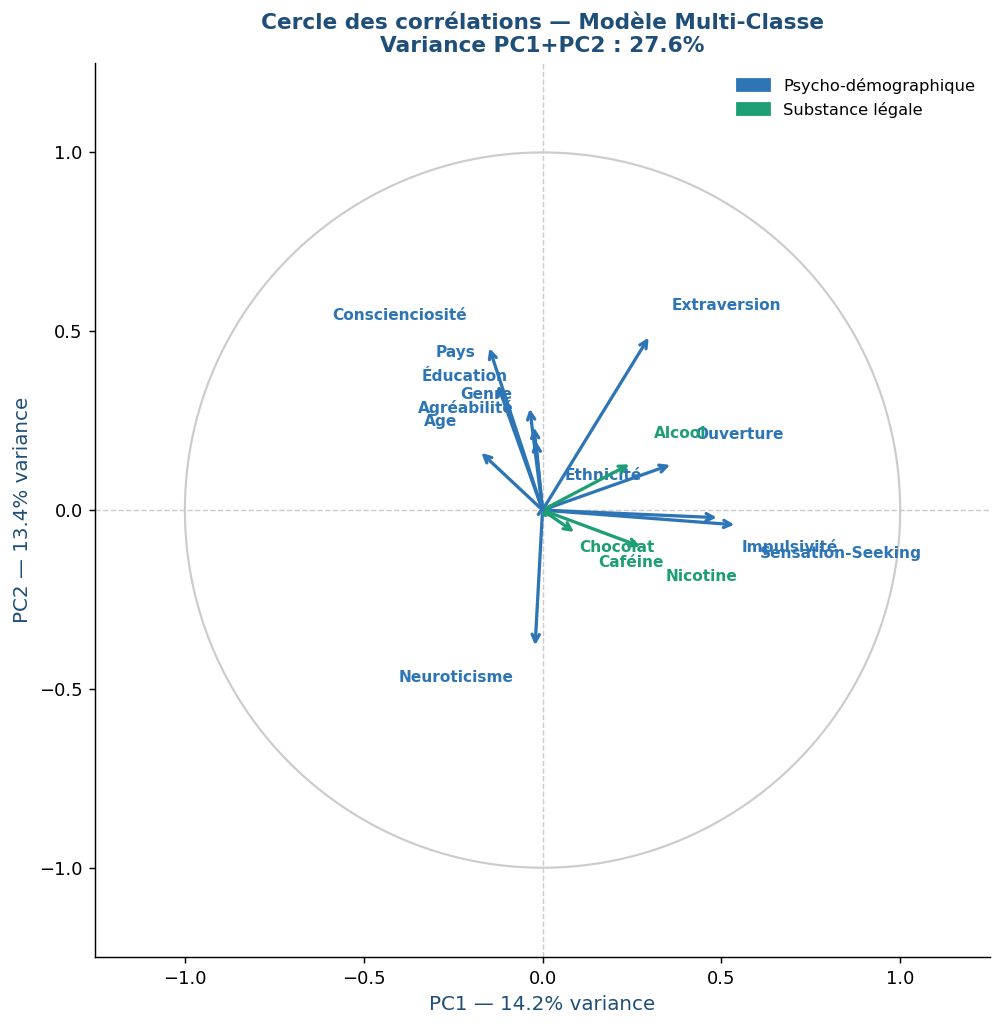

Variance expliquée — PC1: 14.2% | PC2: 13.4% | Total: 27.6%


In [15]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_res)
pca      = PCA(n_components=2, random_state=42)
pca.fit(X_scaled)
loadings = pca.components_.T
v1, v2   = pca.explained_variance_ratio_ * 100

is_legal = ['bin' in c for c in FEATURE_COLS]
labels   = [FEATURE_LABELS[c] for c in FEATURE_COLS]

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('white')
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color='#CCCCCC', linewidth=1.2)
ax.axhline(0, color='#CCCCCC', linewidth=0.8, linestyle='--')
ax.axvline(0, color='#CCCCCC', linewidth=0.8, linestyle='--')

for i, (label, is_l) in enumerate(zip(labels, is_legal)):
    xl, yl = loadings[i, 0], loadings[i, 1]
    color  = GREEN if is_l else LBLUE
    ax.annotate('', xy=(xl, yl), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    ox = 0.06 if xl >= 0 else -0.06
    oy = 0.06 if yl >= 0 else -0.06
    ax.text(xl+ox, yl+oy, label, fontsize=8.5, color=color,
            fontweight='bold', ha='left' if xl>=0 else 'right',
            va='bottom' if yl>=0 else 'top')

ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
ax.set_xlabel(f'PC1 — {v1:.1f}% variance', fontsize=11, color=BLUE)
ax.set_ylabel(f'PC2 — {v2:.1f}% variance', fontsize=11, color=BLUE)
ax.set_title(f'Cercle des corrélations — Modèle Multi-Classe\nVariance PC1+PC2 : {v1+v2:.1f}%',
             fontweight='bold', color=BLUE, fontsize=12)
ax.set_aspect('equal')
p1 = mpatches.Patch(color=LBLUE, label='Psycho-démographique')
p2 = mpatches.Patch(color=GREEN, label='Substance légale')
ax.legend(handles=[p1,p2], frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
print(f'Variance expliquée — PC1: {v1:.1f}% | PC2: {v2:.1f}% | Total: {v1+v2:.1f}%')

> **Comment lire ce graphique ?**  
> Chaque flèche représente une feature. Sa **longueur** indique sa qualité de représentation dans ce plan — une flèche qui atteint le cercle est parfaitement capturée par PC1 et PC2. Sa **direction** indique ses corrélations : deux flèches proches = variables corrélées positivement, opposées = corrélation négative.  
> Si PC1+PC2 explique moins de 40% de la variance, cela confirme que le problème est **multidimensionnel** et que les modèles ensemblistes ont un avantage structurel sur les modèles linéaires.

## 3. PCA — Projection des individus par substance

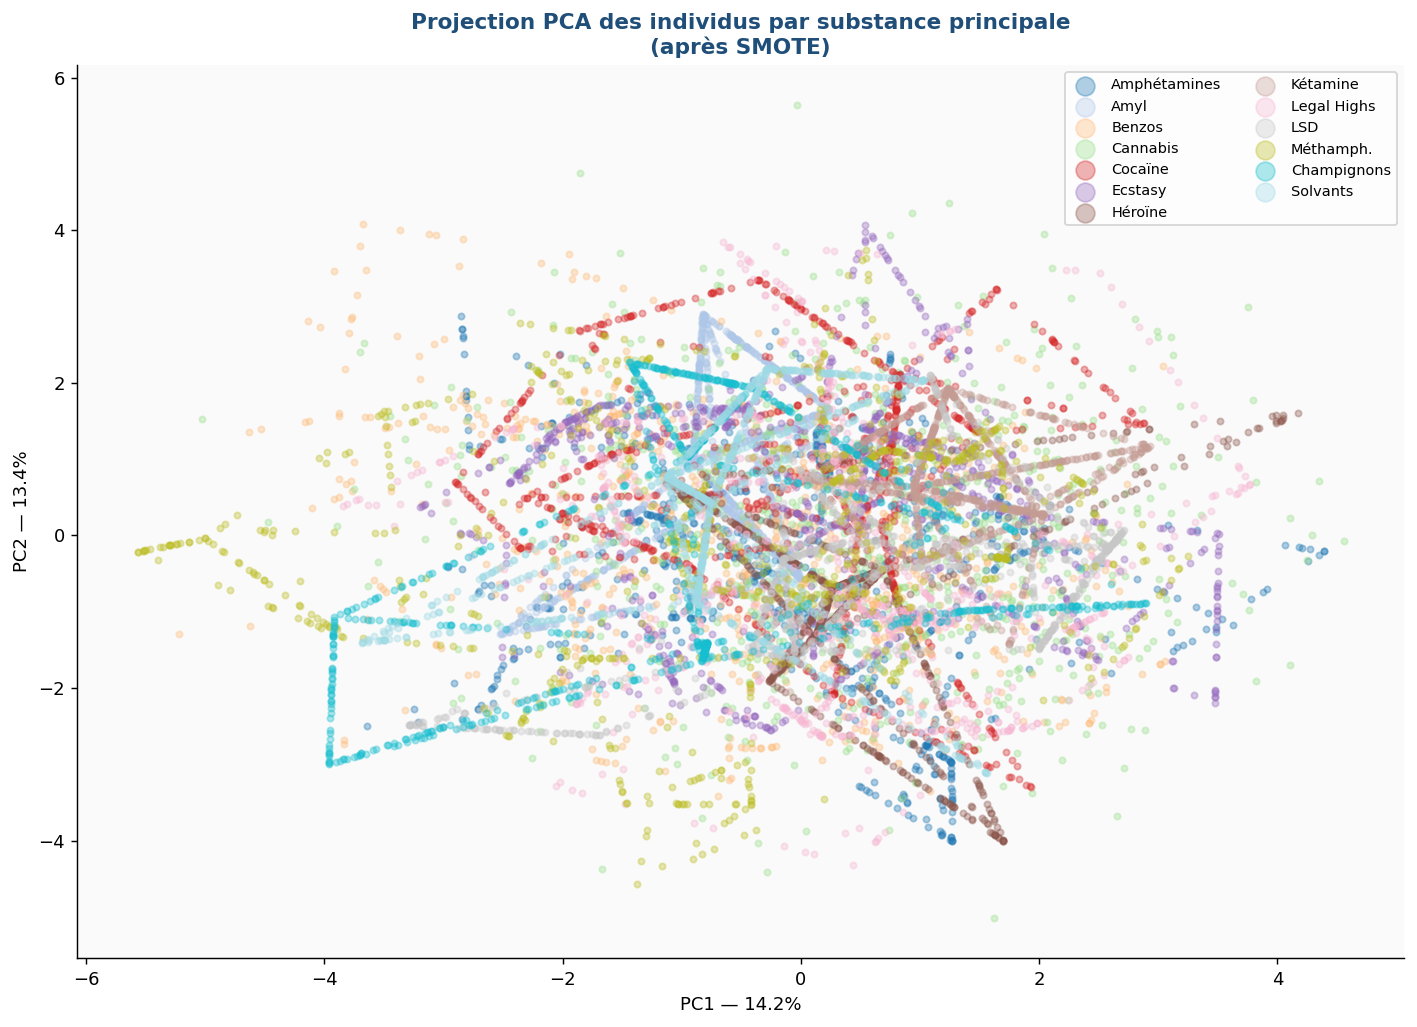

In [16]:
X_pca    = pca.transform(X_scaled)
n_classes = len(classes)
palette   = plt.cm.tab20(np.linspace(0, 1, n_classes))

fig, ax = plt.subplots(figsize=(11, 8))
for i, cls in enumerate(classes):
    mask = y_res == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=palette[i], s=12, alpha=0.35, label=SUBSTANCE_LABELS.get(cls, cls))

ax.set_xlabel(f'PC1 — {v1:.1f}%', fontsize=10)
ax.set_ylabel(f'PC2 — {v2:.1f}%', fontsize=10)
ax.set_title('Projection PCA des individus par substance principale\n(après SMOTE)',
             fontweight='bold', color=BLUE, fontsize=12)
ax.legend(fontsize=8, frameon=True, framealpha=0.8,
          loc='upper right', markerscale=3, ncol=2)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.show()

> **Que cherche-t-on ici ?**  
> Si les nuages de points de chaque substance sont bien **séparés**, le modèle devrait facilement les distinguer. Si les nuages se chevauchent fortement, cela signifie que les deux premières composantes ne suffisent pas à séparer les classes — le modèle exploite des dimensions supplémentaires que la PCA 2D ne montre pas.  
> Un fort chevauchement n'est pas forcément mauvais : il justifie l'utilisation d'un Random Forest plutôt qu'un modèle linéaire.

## 4. Scree Plot — Variance expliquée par composante

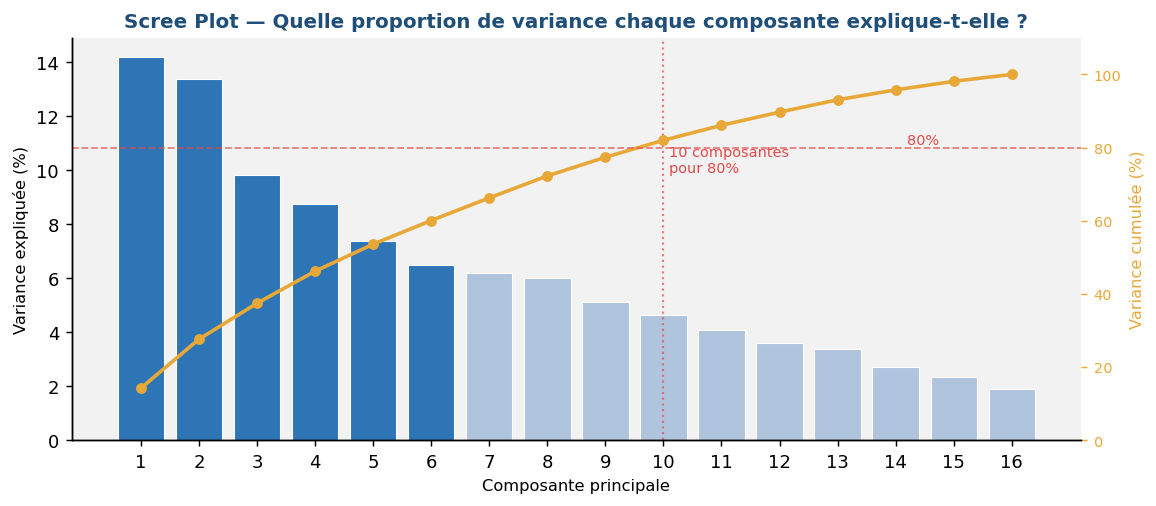

PC1+PC2 = 27.6% | 10 composantes pour atteindre 80%


In [17]:
pca_full  = PCA(n_components=16, random_state=42)
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_ * 100
cumulative= np.cumsum(explained)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 17), explained,
       color=[LBLUE if i < 6 else '#B0C4DE' for i in range(16)],
       edgecolor='white', linewidth=0.6, label='Variance par composante')
ax2 = ax.twinx()
ax2.plot(range(1, 17), cumulative, 'o-', color=ORANGE,
         linewidth=2, markersize=5, label='Variance cumulée')
ax2.axhline(80, color=RED, linestyle='--', linewidth=1, alpha=0.7)
ax2.text(14.2, 81, '80%', color=RED, fontsize=8)
ax2.set_ylabel('Variance cumulée (%)', color=ORANGE, fontsize=9)
ax2.tick_params(colors=ORANGE, labelsize=8)
ax2.set_ylim(0, 110)
ax.set_xlabel('Composante principale', fontsize=9)
ax.set_ylabel('Variance expliquée (%)', fontsize=9)
ax.set_title('Scree Plot — Quelle proportion de variance chaque composante explique-t-elle ?',
             fontweight='bold', color=BLUE, fontsize=11)
ax.set_xticks(range(1, 17))
ax.set_facecolor(LGRAY)

# Nombre de composantes pour 80%
n_80 = np.argmax(cumulative >= 80) + 1
ax.axvline(n_80, color=RED, linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(n_80 + 0.1, max(explained)*0.7, f'{n_80} composantes\npour 80%',
        fontsize=8, color=RED)
plt.tight_layout()
plt.show()
print(f'PC1+PC2 = {explained[0]+explained[1]:.1f}% | {n_80} composantes pour atteindre 80%')

> **Pourquoi ce graphique est important ?**  
> Il répond à la question : "combien de dimensions réelles y a-t-il dans ce dataset ?" Si 80% de la variance nécessite 10 composantes, le problème est intrinsèquement multidimensionnel. Cela justifie l'utilisation d'un Random Forest qui exploite toutes les dimensions simultanément, plutôt qu'une régression logistique limitée aux relations linéaires.

## 5. Matrice de confusion

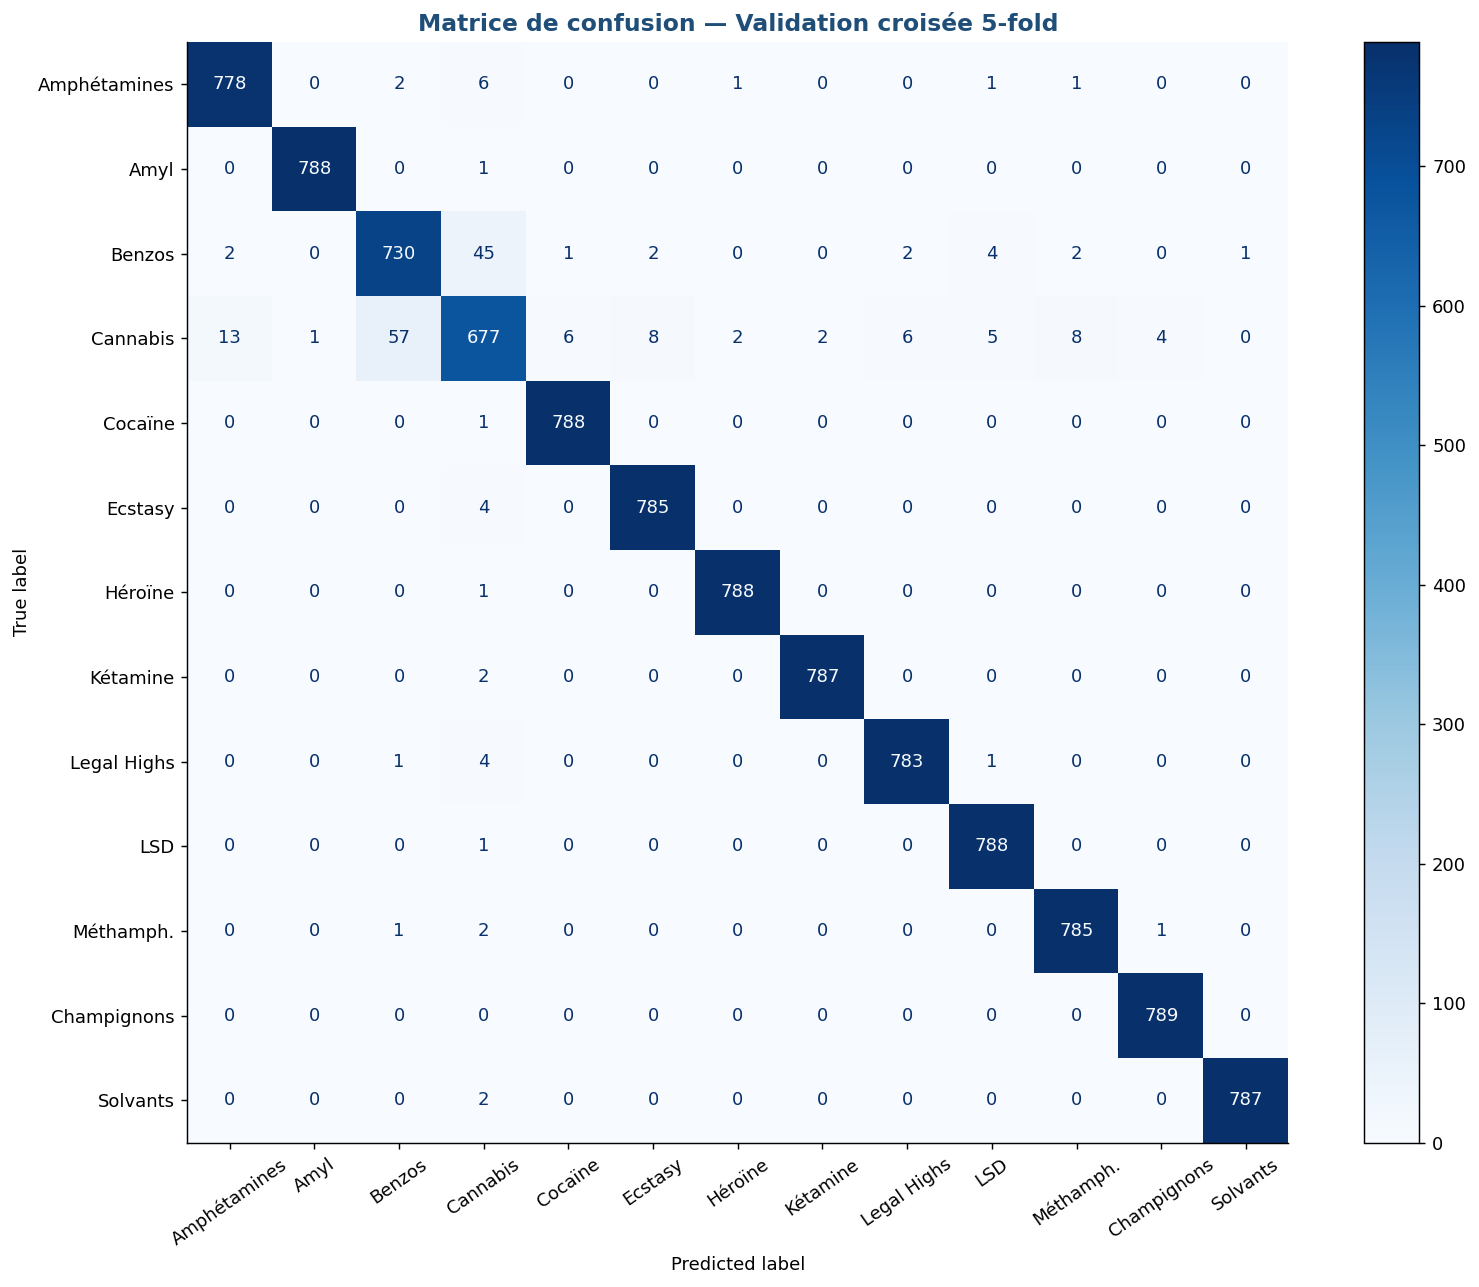

F1 macro    : 0.980
F1 weighted : 0.980


In [18]:
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(rf_multi, X_res, y_res, cv=cv)
cm     = confusion_matrix(y_res, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(13, 10))
ConfusionMatrixDisplay(cm, display_labels=[
    SUBSTANCE_LABELS.get(c, c) for c in classes
]).plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=35)
ax.set_title('Matrice de confusion — Validation croisée 5-fold',
             fontweight='bold', color=BLUE, fontsize=13)
plt.tight_layout()
plt.show()

print(f'F1 macro    : {f1_score(y_res, y_pred, average="macro"):.3f}')
print(f'F1 weighted : {f1_score(y_res, y_pred, average="weighted"):.3f}')

> **Comment lire la matrice de confusion ?**  
> Chaque ligne = la vraie substance. Chaque colonne = ce que le modèle a prédit. Les valeurs sur la **diagonale** sont les bonnes prédictions. Les valeurs **hors diagonale** sont les erreurs — on voit précisément quelle substance est confondue avec quelle autre.  
> Par exemple, si beaucoup d'ecstasy sont prédit comme cannabis, cela indique que ces deux profils se ressemblent dans les données.

## 6. Analyse détaillée des erreurs

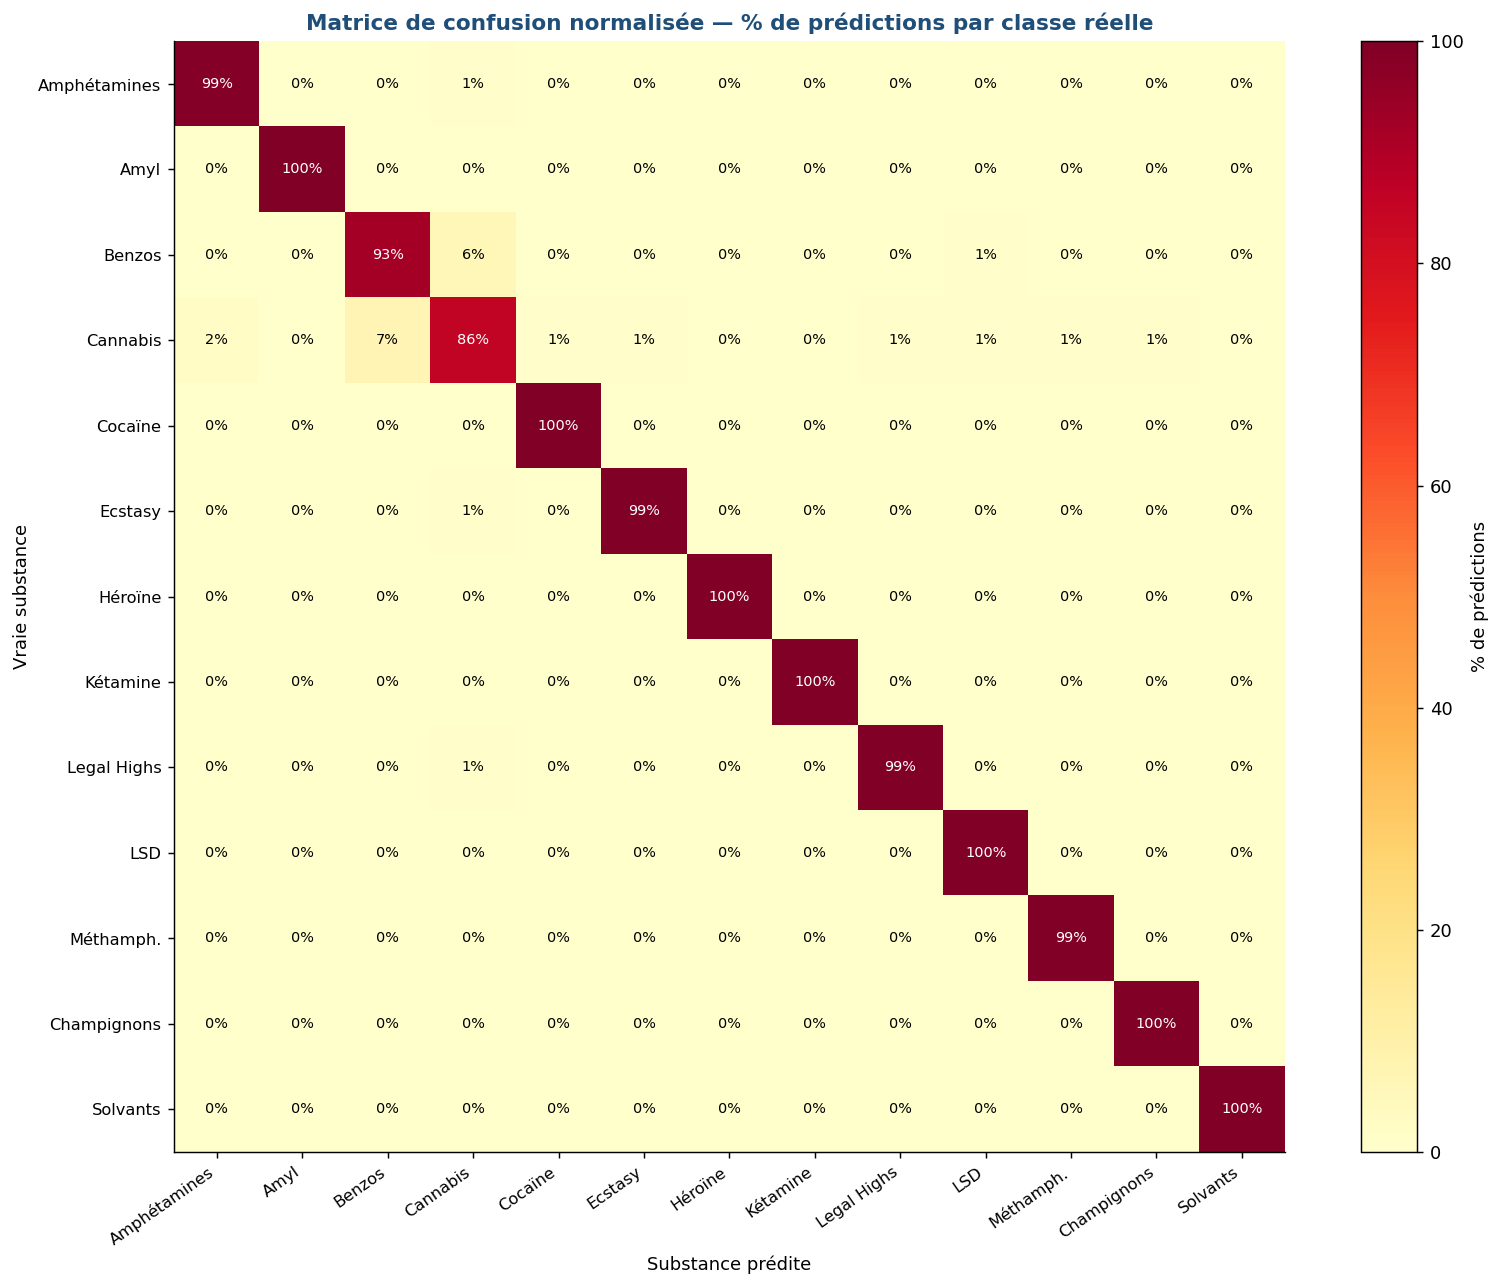

Top 5 confusions :
  Cannabis           prédit comme Benzos             : 57 cas (7%)
  Benzos             prédit comme Cannabis           : 45 cas (6%)
  Cannabis           prédit comme Amphétamines       : 13 cas (2%)
  Cannabis           prédit comme Méthamph.          : 8 cas (1%)
  Cannabis           prédit comme Ecstasy            : 8 cas (1%)


In [19]:
# Matrice de confusion normalisée (en % par ligne)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(cm_norm, cmap='YlOrRd', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='% de prédictions')

tick_labels = [SUBSTANCE_LABELS.get(c, c) for c in classes]
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(tick_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(tick_labels, fontsize=9)

for i in range(len(classes)):
    for j in range(len(classes)):
        val = cm_norm[i, j]
        color = 'white' if val > 60 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=8, color=color)

ax.set_ylabel('Vraie substance', fontsize=10)
ax.set_xlabel('Substance prédite', fontsize=10)
ax.set_title('Matrice de confusion normalisée — % de prédictions par classe réelle',
             fontweight='bold', color=BLUE, fontsize=12)
plt.tight_layout()
plt.show()

# Top erreurs
print('Top 5 confusions :')
errors = []
for i, true_cls in enumerate(classes):
    for j, pred_cls in enumerate(classes):
        if i != j and cm[i, j] > 0:
            errors.append((cm[i,j], true_cls, pred_cls, cm_norm[i,j]))
errors.sort(reverse=True)
for count, true_c, pred_c, pct in errors[:5]:
    print(f'  {SUBSTANCE_LABELS.get(true_c,true_c):<18} prédit comme {SUBSTANCE_LABELS.get(pred_c,pred_c):<18} : {count} cas ({pct:.0f}%)')

> **Matrice normalisée vs brute — quelle différence ?**  
> La matrice brute montre les **volumes** d'erreurs. La normalisée montre les **taux** d'erreurs par classe.  
> La version normalisée est plus honnête avec le SMOTE : comme toutes les classes ont le même nombre d'individus après rééquilibrage, les taux sont directement comparables.  
> Les confusions les plus fréquentes révèlent des substances aux profils psychologiques similaires.

## 7. Feature importances globales

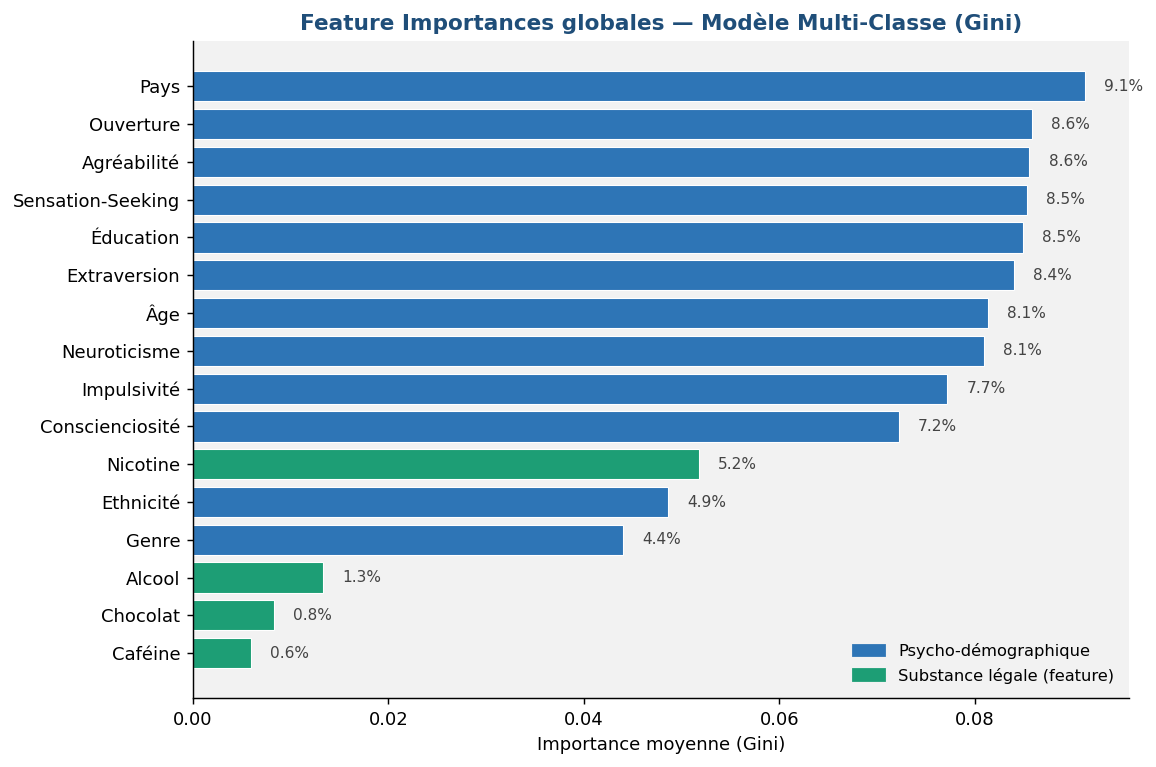

Ranking des features :
  Pays                   : 9.1%
  Ouverture              : 8.6%
  Agréabilité            : 8.6%
  Sensation-Seeking      : 8.5%
  Éducation              : 8.5%
  Extraversion           : 8.4%
  Âge                    : 8.1%
  Neuroticisme           : 8.1%
  Impulsivité            : 7.7%
  Conscienciosité        : 7.2%
  Nicotine               : 5.2%
  Ethnicité              : 4.9%
  Genre                  : 4.4%
  Alcool                 : 1.3%
  Chocolat               : 0.8%
  Caféine                : 0.6%


In [20]:
importances = rf_multi.feature_importances_
labels_feat = [FEATURE_LABELS[c] for c in FEATURE_COLS]
is_legal    = ['bin' in c for c in FEATURE_COLS]
idx_sorted  = np.argsort(importances)
colors_imp  = [GREEN if is_legal[i] else LBLUE for i in idx_sorted]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(np.array(labels_feat)[idx_sorted], importances[idx_sorted],
               color=colors_imp, edgecolor='white', linewidth=0.6)
# Annotation des valeurs
for bar, i in zip(bars, idx_sorted):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{importances[i]*100:.1f}%', va='center', fontsize=8.5, color='#444')
ax.set_title('Feature Importances globales — Modèle Multi-Classe (Gini)',
             fontweight='bold', color=BLUE, fontsize=12)
ax.set_xlabel('Importance moyenne (Gini)')
ax.set_facecolor(LGRAY)
p1 = mpatches.Patch(color=LBLUE, label='Psycho-démographique')
p2 = mpatches.Patch(color=GREEN, label='Substance légale (feature)')
ax.legend(handles=[p1,p2], frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print('Ranking des features :')
for i in np.argsort(importances)[::-1]:
    print(f'  {FEATURE_LABELS[FEATURE_COLS[i]]:<22} : {importances[i]*100:.1f}%')

> **Comment interpréter les feature importances ?**  
> L'importance Gini mesure combien chaque feature contribue à réduire l'impureté des nœuds dans les arbres.  
> Une feature avec une importance élevée est **discriminante** : elle aide le modèle à séparer les substances les unes des autres.  
> Si le Sensation-Seeking ou l'Ouverture dominent, cela confirme la littérature en psychologie addictive : ces traits sont les plus prédictifs du type de substance consommée.

## 8. Rapport de classification complet

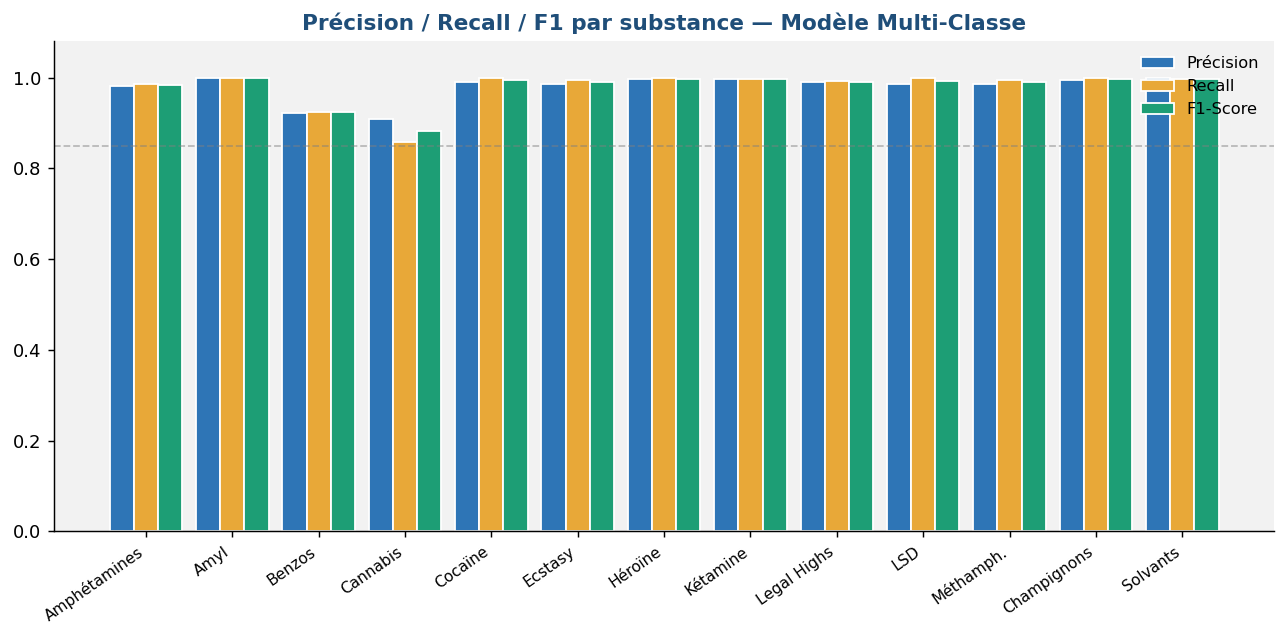

              precision  recall  f1-score  support
Amphétamines      0.981   0.986     0.984    789.0
Amyl              0.999   0.999     0.999    789.0
Benzos            0.923   0.925     0.924    789.0
Cannabis          0.908   0.858     0.882    789.0
Cocaïne           0.991   0.999     0.995    789.0
Ecstasy           0.987   0.995     0.991    789.0
Héroïne           0.996   0.999     0.997    789.0
Kétamine          0.997   0.997     0.997    789.0
Legal Highs       0.990   0.992     0.991    789.0
LSD               0.986   0.999     0.992    789.0
Méthamph.         0.986   0.995     0.991    789.0
Champignons       0.994   1.000     0.997    789.0
Solvants          0.999   0.997     0.998    789.0


In [21]:
report = classification_report(
    y_res, y_pred,
    target_names=[SUBSTANCE_LABELS.get(c, c) for c in classes],
    output_dict=True
)
df_report = pd.DataFrame(report).T.round(3)
df_report = df_report[df_report.index.isin(
    [SUBSTANCE_LABELS.get(c, c) for c in classes]
)][['precision','recall','f1-score','support']]

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(classes))
w = 0.28
ax.bar(x - w, df_report['precision'],  w, label='Précision', color=LBLUE,   edgecolor='white')
ax.bar(x,     df_report['recall'],     w, label='Recall',    color=ORANGE,  edgecolor='white')
ax.bar(x + w, df_report['f1-score'],   w, label='F1-Score',  color=GREEN,   edgecolor='white')
ax.axhline(0.85, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([SUBSTANCE_LABELS.get(c,c) for c in classes],
                   rotation=35, ha='right', fontsize=8.5)
ax.set_ylim(0, 1.08)
ax.set_title('Précision / Recall / F1 par substance — Modèle Multi-Classe',
             fontweight='bold', color=BLUE, fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.set_facecolor(LGRAY)
plt.tight_layout()
plt.show()

print(df_report.to_string())

> **Precision vs Recall — quelle différence ?**  
> La **précision** mesure : parmi tous les individus classés comme "consommateur d'ecstasy", combien l'étaient vraiment ?  
> Le **recall** mesure : parmi tous les vrais consommateurs d'ecstasy, combien ont été correctement identifiés ?  
> Dans un contexte médical, le recall est prioritaire — manquer un vrai consommateur est plus grave que déclencher une fausse alerte.  
> Le **F1** est la moyenne harmonique des deux — il équilibre les deux objectifs.

## 9. Profils moyens par substance (centroids)

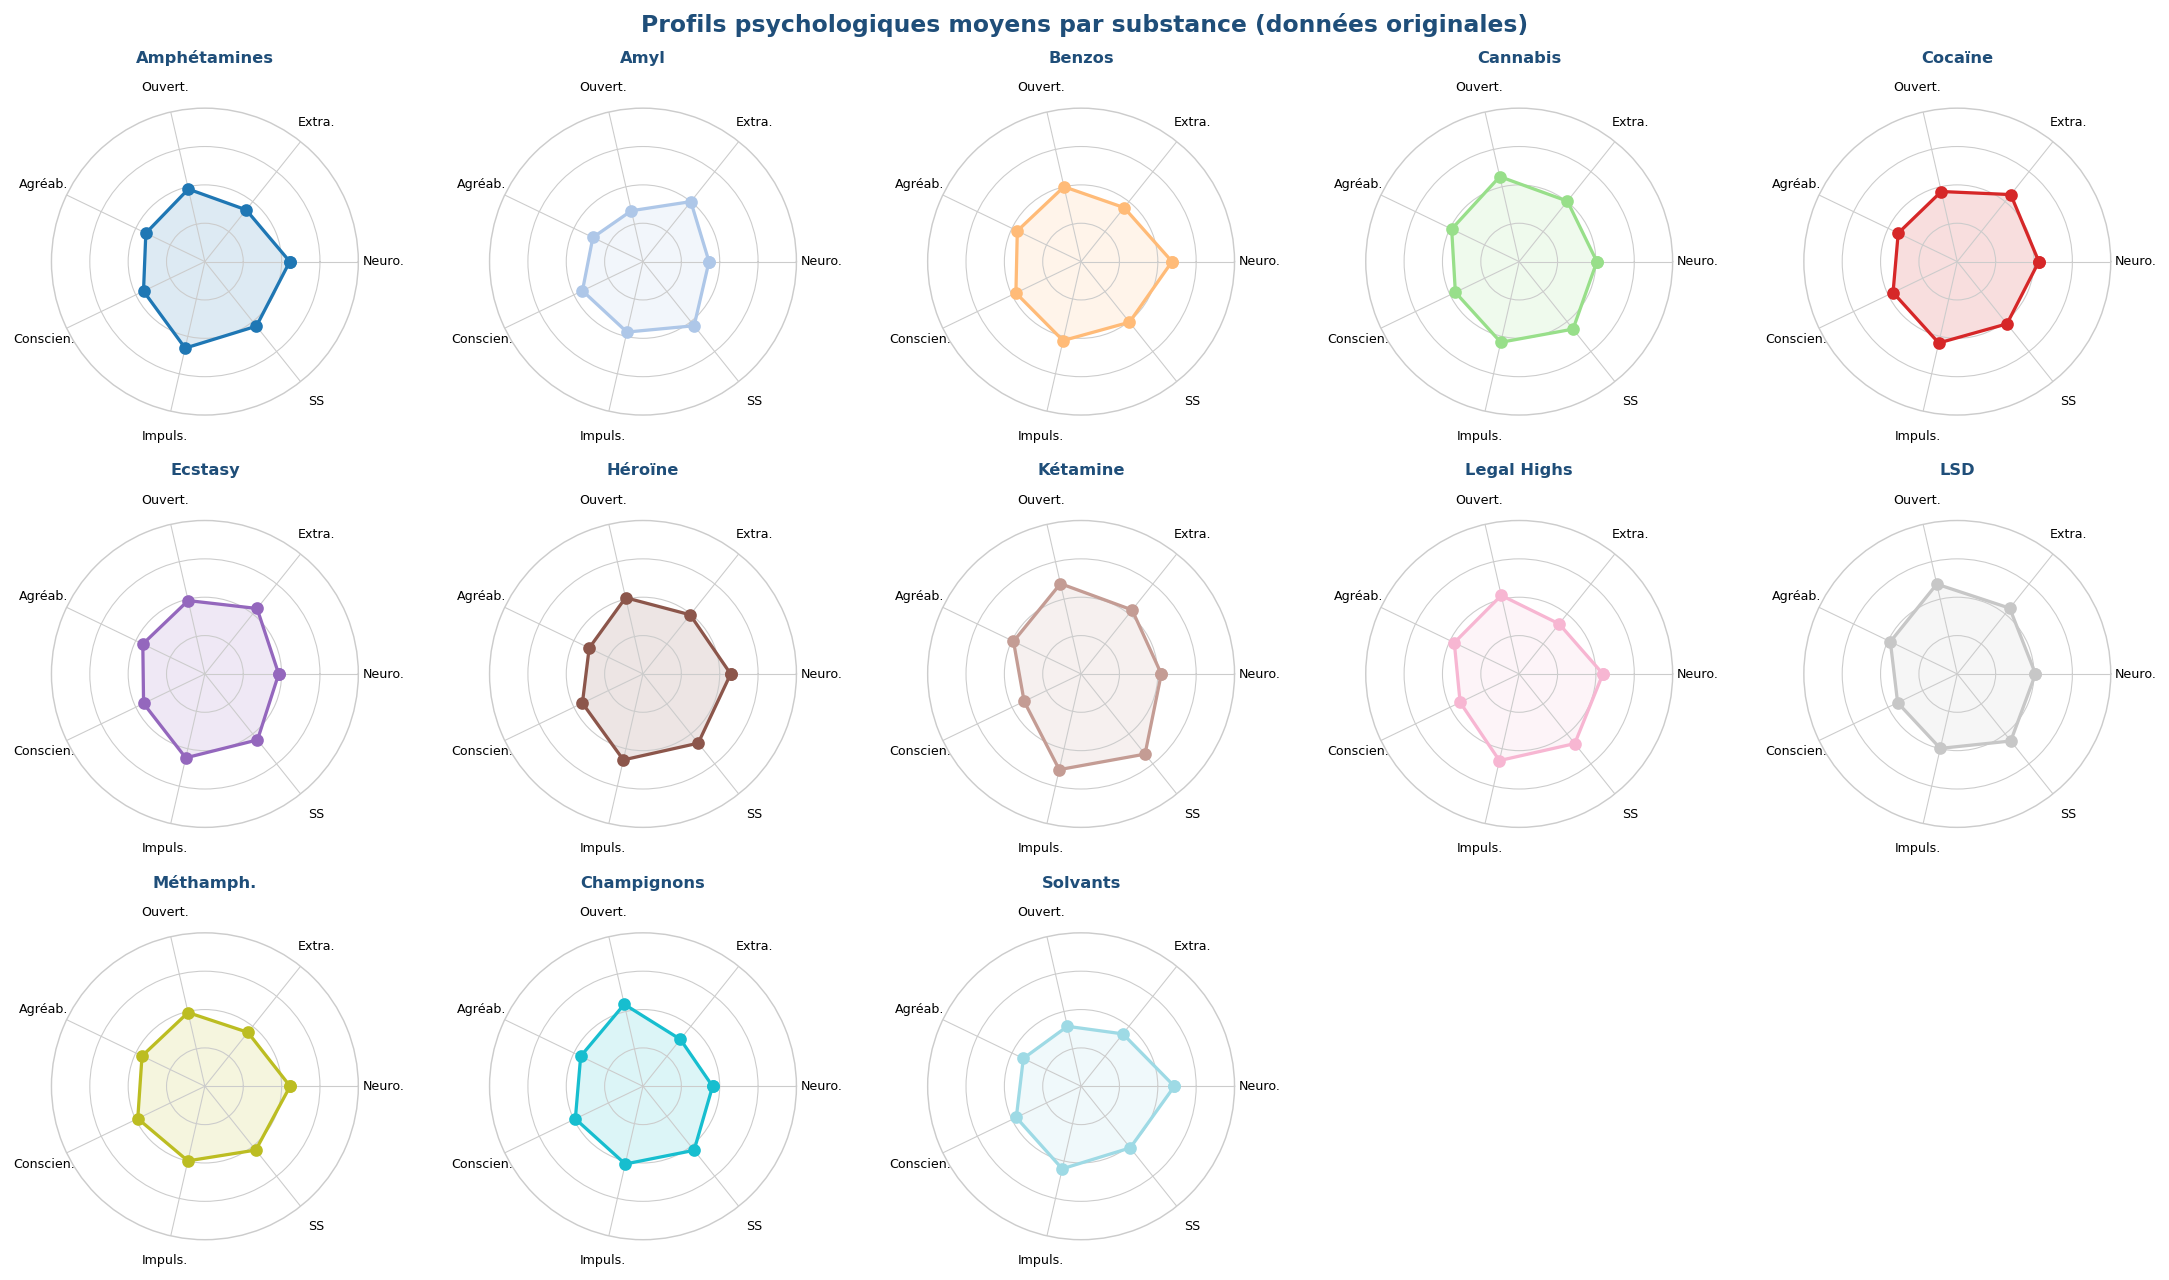

In [22]:
# Calcul du profil moyen par substance sur les données originales (avant SMOTE)
psycho_cols = ['nscore','escore','oscore','ascore','cscore','impulsive','ss']
psycho_labels = ['Neuro.','Extra.','Ouvert.','Agréab.','Conscien.','Impuls.','SS']

n_classes = len(classes)
fig, axes = plt.subplots(3, 5, figsize=(17, 10), subplot_kw=dict(polar=True))
fig.suptitle('Profils psychologiques moyens par substance (données originales)',
             fontweight='bold', color=BLUE, fontsize=13)
axes = axes.flatten()

N = len(psycho_cols)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]
palette = plt.cm.tab20(np.linspace(0, 1, n_classes))

for i, cls in enumerate(classes):
    ax = axes[i]
    mask = df_recent['primary_substance'] == cls
    vals = df_recent.loc[mask, psycho_cols].mean().values.tolist()
    # Normalisation 0-1 pour le radar
    vals_norm = [(v + 3) / 6 for v in vals] + [(vals[0] + 3) / 6]

    ax.plot(angles, vals_norm, 'o-', linewidth=1.8, color=palette[i])
    ax.fill(angles, vals_norm, alpha=0.15, color=palette[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(psycho_labels, fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels([], fontsize=0)
    ax.set_title(SUBSTANCE_LABELS.get(cls, cls), fontsize=9,
                 fontweight='bold', color=BLUE, pad=10)
    ax.grid(color='#CCCCCC', linewidth=0.6)
    ax.spines['polar'].set_color('#CCCCCC')

# Masquer les axes vides
for j in range(n_classes, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

> **Pourquoi ces radars ?**  
> Ils montrent le **profil psychologique moyen** des consommateurs de chaque substance.  
> C'est la visualisation métier la plus parlante : on peut voir en un coup d'œil que les consommateurs de LSD ont un profil "ouverture élevée", que les consommateurs d'héroïne ont un profil "neuroticisme élevé + conscienciosité faible", etc.  
> Des profils très différents entre substances = le modèle devrait bien les distinguer. Des profils similaires = zone de confusion probable.